# Analyse des Anomalies — Moteur de Règles Déterministe

**Pipeline** :
1. Chargement du CSV scoré (`isolation_forest_v4_scored_full.csv`) + dataset brut
2. Calcul des références statistiques sur les observations normales
3. Application des règles métier sur chaque anomalie mid/high
4. Exploration interactive des résultats

> **Pré-requis** : avoir exécuté `isolation_forest_v4.py` pour générer `isolation_forest_v4_scored_full.csv`

---
## Cellule 0 — Configuration des chemins

In [1]:
# ============================================================
# MODIFIE CES CHEMINS SELON TON ENVIRONNEMENT
# ============================================================
SCORED_CSV  = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\outputs\oneclass_svm_v1_scored_full.csv"
RAW_CSV     = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\Raw\energydata_complete.csv"
OUTPUT_DIR  = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\outputs"
OUTPUT_CSV  = OUTPUT_DIR + r"anomaly_analysis_report_oneclass_SVM.csv"

# Categories a analyser
TARGET_CATEGORIES = ["mid", "high"]

# Seuils de qualification contextuelle (percentiles vs observations normales)
Q_TRES_HAUT = 90
Q_HAUT      = 75
Q_BAS       = 25
Q_TRES_BAS  = 10

# Seuils metier absolus
APPLIANCES_VEILLE    = 30
APPLIANCES_ELEVE     = 200
LIGHTS_ETEINT        = 5
LIGHTS_ALLUME        = 50
T_OUT_FROID          = 5
T_OUT_DOUX           = 12
T_OUT_CHAUD          = 20
T_INDOOR_CONFORT_MIN = 18
T_INDOOR_CHAUD       = 24
RH_HUMIDE            = 70
RH_SEC               = 30
WIND_FORT            = 5

print("Configuration OK")

Configuration OK


---
## Cellule 1 — Imports

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)

print("Imports OK")

Imports OK


---
## Cellule 2 — Chargement des données

In [3]:
# Chargement du CSV scoré (sortie isolation_forest_v4)
df_scored = pd.read_csv(SCORED_CSV, parse_dates=["date"])

# Chargement du dataset brut original (toutes les colonnes capteurs)
df_raw = pd.read_csv(RAW_CSV, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)
df_raw["hour"]       = df_raw["date"].dt.hour
df_raw["is_weekend"] = (df_raw["date"].dt.dayofweek >= 5).astype(int)

# Jointure : on recupere TOUTES les colonnes brutes pour les anomalies
# Les colonnes deja presentes dans scored sont exclues (sauf 'date' pour la jointure)
cols_to_add = [c for c in df_raw.columns if c not in df_scored.columns or c == "date"]
df_anomalies = df_scored[df_scored["anomaly_category"].isin(TARGET_CATEGORIES)].copy()
df_anomalies = df_anomalies.merge(df_raw[cols_to_add], on="date", how="left")
df_anomalies = df_anomalies.sort_values("date").reset_index(drop=True)

print(f"Dataset brut        : {len(df_raw):,} lignes x {len(df_raw.columns)} colonnes")
print(f"Dataset scoré       : {len(df_scored):,} lignes")
print(f"Anomalies mid+high  : {len(df_anomalies):,}")
print(f"\nDistribution :")
print(df_scored["anomaly_category"].value_counts().to_string())

Dataset brut        : 19,735 lignes x 31 colonnes
Dataset scoré       : 19,735 lignes
Anomalies mid+high  : 1,142

Distribution :
anomaly_category
normal    17501
low        1092
mid         926
high        216


---
## Cellule 3 — Références statistiques sur les observations normales

Les seuils sont calculés **uniquement sur les observations normales** pour ne pas être contaminés par les anomalies.

In [4]:
SENSORS_TO_QUALIFY = [
    "Appliances", "lights",
    "T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", "T_out",
    "RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_6", "RH_7", "RH_8", "RH_9", "RH_out",
    "Press_mm_hg", "Windspeed", "Tdewpoint",
]

ROOM_NAMES = {
    "T1":"cuisine", "T2":"salon/salle de vie", "T3":"buanderie",
    "T4":"bureau", "T5":"salle de bain", "T6":"exterieur Nord",
    "T7":"chambre parentale", "T8":"salon ado", "T9":"chambre",
}
ROOM_NAMES_RH = {
    "RH_1":"cuisine", "RH_2":"salon/salle de vie", "RH_3":"buanderie",
    "RH_4":"bureau", "RH_5":"salle de bain", "RH_6":"exterieur Nord",
    "RH_7":"chambre parentale", "RH_8":"salon ado", "RH_9":"chambre",
}

# Reconstruction du dataset normal avec toutes les colonnes brutes
df_normal = df_scored[df_scored["anomaly_category"] == "normal"].copy()
df_normal = df_normal.merge(df_raw[cols_to_add], on="date", how="left")
df_normal["hour"] = df_normal["date"].dt.hour

# Calcul des percentiles par heure du jour pour chaque capteur
ref_stats = {}
for sensor in SENSORS_TO_QUALIFY:
    if sensor not in df_normal.columns:
        continue
    ref_stats[sensor] = {}
    for h in range(24):
        vals = df_normal[df_normal["hour"] == h][sensor].dropna().values
        ref_stats[sensor][h] = np.sort(vals) if len(vals) > 0 else np.array([0.0])

print(f"Références calculées sur {len(df_normal):,} observations normales")
print(f"Capteurs couverts : {len(ref_stats)}")

# Verification rapide : percentiles de Appliances a 8h
ref_8h = ref_stats["Appliances"][8]
print(f"\nAppliances à 8h (normaux) — Q25={np.percentile(ref_8h,25):.0f} Q50={np.percentile(ref_8h,50):.0f} Q75={np.percentile(ref_8h,75):.0f} Q90={np.percentile(ref_8h,90):.0f} Wh")

Références calculées sur 17,501 observations normales
Capteurs couverts : 25

Appliances à 8h (normaux) — Q25=50 Q50=60 Q75=90 Q90=234 Wh


---
## Cellule 4 — Fonctions utilitaires

In [5]:
def get_pct(sensor, value, hour):
    """Percentile contextuel d'une valeur par rapport aux normaux à la même heure."""
    ref = ref_stats.get(sensor, {}).get(hour, np.array([0.0]))
    return float(np.searchsorted(ref, value, side="right") / len(ref) * 100)

def qualify(sensor, value, hour):
    pct = get_pct(sensor, value, hour)
    if pct >= Q_TRES_HAUT: return "TRES_HAUT"
    if pct >= Q_HAUT:      return "HAUT"
    if pct <= Q_TRES_BAS:  return "TRES_BAS"
    if pct <= Q_BAS:       return "BAS"
    return "NORMAL"

def pct_label(pct):
    if pct >= 95: return "extremement eleve (top 5%)"
    if pct >= 90: return "tres eleve (top 10%)"
    if pct >= 75: return "au-dessus de la normale (top 25%)"
    if pct <= 5:  return "extremement bas (bottom 5%)"
    if pct <= 10: return "tres bas (bottom 10%)"
    if pct <= 25: return "en dessous de la normale (bottom 25%)"
    return "dans la plage normale"

def season(month):
    if month in (12,1,2): return "hiver"
    if month in (3,4,5):  return "printemps"
    if month in (6,7,8):  return "ete"
    return "automne"

def time_slot(hour):
    if 0  <= hour < 6:  return "nuit (0h-6h)"
    if 6  <= hour < 9:  return "matin (6h-9h)"
    if 9  <= hour < 12: return "matinee (9h-12h)"
    if 12 <= hour < 14: return "midi (12h-14h)"
    if 14 <= hour < 18: return "apres-midi (14h-18h)"
    if 18 <= hour < 22: return "soiree (18h-22h)"
    return "nuit tardive (22h-0h)"

print("Fonctions utilitaires chargées")

Fonctions utilitaires chargées


---
## Cellule 5 — Règles métier

Chaque règle retourne `None` si elle ne s'applique pas, ou un dictionnaire avec `code`, `severity`, `categorie`, `titre`, `detail`.

In [6]:
def rule_energy_night_activity(ctx):
    if not (0 <= ctx["hour"] <= 5
            and ctx["Appliances"] > APPLIANCES_VEILLE
            and ctx["q_Appliances"] in ("TRES_HAUT","HAUT")):
        return None
    lights_str = (f"avec eclairage ({ctx['lights']:.0f} Wh)"
                  if ctx["lights"] > LIGHTS_ETEINT else "sans eclairage")
    return {
        "code":"ENERGY_NIGHT_ACTIVITY", "severity":"critique" if ctx["lights"]>LIGHTS_ALLUME else "elevee",
        "categorie":"energie", "titre":"Activite electrique anormale en pleine nuit",
        "detail":(
            f"Consommation de {ctx['Appliances']:.0f} Wh a {ctx['hour']}h "
            f"({pct_label(ctx['pct_Appliances'])} pour cette heure) {lights_str}. "
            f"Peut indiquer un appareil defaillant, un cycle programme (lave-linge, "
            f"lave-vaisselle) ou une presence inhabituelle dans le logement."
        ),
    }

def rule_energy_peak_no_light(ctx):
    if not (ctx["Appliances"] > APPLIANCES_ELEVE
            and ctx["lights"] < LIGHTS_ETEINT
            and ctx["q_Appliances"] in ("TRES_HAUT","HAUT")
            and 7 <= ctx["hour"] <= 22):
        return None
    return {
        "code":"ENERGY_PEAK_NO_LIGHT", "severity":"elevee" if ctx["Appliances"]>400 else "moderee",
        "categorie":"energie", "titre":"Surconsommation d'appareils sans eclairage",
        "detail":(
            f"Les appareils consomment {ctx['Appliances']:.0f} Wh "
            f"({pct_label(ctx['pct_Appliances'])} pour {ctx['hour']}h), "
            f"alors que l'eclairage est quasi nul ({ctx['lights']:.0f} Wh). "
            f"Probable usage intensif d'appareils electromenagers (cuisine, buanderie) "
            f"sans presence dans les pieces de vie."
        ),
    }

def rule_energy_peak_with_light(ctx):
    if not (ctx["Appliances"] > APPLIANCES_ELEVE
            and ctx["lights"] > LIGHTS_ALLUME
            and ctx["q_Appliances"] in ("TRES_HAUT","HAUT")):
        return None
    return {
        "code":"ENERGY_PEAK_WITH_LIGHT", "severity":"elevee" if ctx["Appliances"]>500 else "moderee",
        "categorie":"energie", "titre":"Pic de consommation globale (appareils + eclairage)",
        "detail":(
            f"Consommation elevee des appareils ({ctx['Appliances']:.0f} Wh, "
            f"{pct_label(ctx['pct_Appliances'])} pour {ctx['hour']}h) "
            f"accompagnee d'un eclairage important ({ctx['lights']:.0f} Wh). "
            f"Activite domestique intense inhabituelle pour ce creneau."
        ),
    }

def rule_energy_standby_anomaly(ctx):
    if not (ctx["Appliances"] < APPLIANCES_VEILLE*2
            and ctx["lights"] < LIGHTS_ETEINT
            and ctx["q_Appliances"] in ("TRES_HAUT","HAUT")):
        return None
    return {
        "code":"ENERGY_STANDBY_ANOMALY", "severity":"moderee",
        "categorie":"energie", "titre":"Consommation de veille anormalement elevee",
        "detail":(
            f"Veille a {ctx['Appliances']:.0f} Wh ({pct_label(ctx['pct_Appliances'])} pour {ctx['hour']}h) "
            f"sans eclairage. Equipement ne passant pas en veille profonde, "
            f"chauffe-eau, congelateur en degivrage ou perte en ligne."
        ),
    }

def rule_therm_hot_indoor_mild_outdoor(ctx):
    t_vals = {k:ctx[k] for k in ["T1","T2","T3"] if not np.isnan(ctx.get(k,np.nan))}
    if not t_vals: return None
    t_max_key = max(t_vals, key=t_vals.get)
    t_max_val = t_vals[t_max_key]
    if not (t_max_val > T_INDOOR_CHAUD
            and ctx["T_out"] > T_OUT_DOUX
            and ctx["q_T2"] in ("TRES_HAUT","HAUT")):
        return None
    return {
        "code":"THERM_HOT_INDOOR_MILD_OUTDOOR", "severity":"moderee",
        "categorie":"thermique", "titre":"Surchauffe interieure par temps exterieur doux",
        "detail":(
            f"Temperature interieure maximale de {t_max_val:.1f}C "
            f"({ROOM_NAMES.get(t_max_key,t_max_key)}) alors que T_out={ctx['T_out']:.1f}C (temps doux). "
            f"Accumulation de chaleur liee a la consommation des appareils ({ctx['Appliances']:.0f} Wh) "
            f"sans ventilation naturelle."
        ),
    }

def rule_therm_cold_indoor(ctx):
    t_min = min(ctx.get("T1",99), ctx.get("T2",99), ctx.get("T7",99))
    if not (t_min < T_INDOOR_CONFORT_MIN
            and ctx["T_out"] < T_OUT_FROID
            and ctx["q_T2"] in ("TRES_BAS","BAS")):
        return None
    return {
        "code":"THERM_COLD_INDOOR", "severity":"elevee",
        "categorie":"thermique", "titre":"Sous-temperature interieure par temps froid",
        "detail":(
            f"Temperature interieure minimale a {t_min:.1f}C (seuil confort={T_INDOOR_CONFORT_MIN}C) "
            f"avec T_out={ctx['T_out']:.1f}C. "
            f"Systeme de chauffage insuffisant ou defaillant."
        ),
    }

def rule_therm_asymmetry(ctx):
    temps = {k:ctx[k] for k in ["T1","T2","T3","T4","T5","T7","T8","T9"]
             if not np.isnan(ctx.get(k,np.nan))}
    if not temps: return None
    t_max_k = max(temps, key=temps.get)
    t_min_k = min(temps, key=temps.get)
    spread  = temps[t_max_k] - temps[t_min_k]
    if spread < 8: return None
    return {
        "code":"THERM_ASYMMETRY", "severity":"moderee",
        "categorie":"thermique", "titre":"Forte disparite thermique entre les pieces",
        "detail":(
            f"Ecart de {spread:.1f}C entre {ROOM_NAMES.get(t_max_k,t_max_k)} ({temps[t_max_k]:.1f}C) "
            f"et {ROOM_NAMES.get(t_min_k,t_min_k)} ({temps[t_min_k]:.1f}C). "
            f"Source de chaleur localisee (four, seche-linge) ou absence de circulation d'air."
        ),
    }

def rule_hyg_bathroom_spike(ctx):
    rh5 = ctx.get("RH_5", np.nan)
    if np.isnan(rh5): return None
    if not (rh5 > RH_HUMIDE and ctx.get("q_RH_5","NORMAL") in ("TRES_HAUT","HAUT")):
        return None
    hors_horaire = not (6<=ctx["hour"]<=9 or 19<=ctx["hour"]<=22)
    timing = "hors des creneaux habituels" if hors_horaire else "sur creneau habituel"
    return {
        "code":"HYG_BATHROOM_SPIKE", "severity":"moderee" if hors_horaire else "basse",
        "categorie":"hygrique", "titre":"Humidite elevee en salle de bain",
        "detail":(
            f"Humidite salle de bain : {rh5:.0f}% ({pct_label(ctx['pct_RH_5'])} pour {ctx['hour']}h), "
            f"{timing}. Douche/bain prolonge ou ventilation insuffisante."
        ),
    }

def rule_hyg_laundry_spike(ctx):
    rh3 = ctx.get("RH_3", np.nan)
    if np.isnan(rh3): return None
    if not (rh3 > RH_HUMIDE and ctx.get("q_RH_3","NORMAL") in ("TRES_HAUT","HAUT")):
        return None
    combined = ctx["Appliances"] > APPLIANCES_ELEVE
    app_note = (f"combinee a consommation elevee ({ctx['Appliances']:.0f} Wh) — cycle lave-linge probable"
                if combined else "sans pic de consommation associe")
    return {
        "code":"HYG_LAUNDRY_SPIKE", "severity":"moderee",
        "categorie":"hygrique", "titre":"Humidite elevee en buanderie",
        "detail":(
            f"Humidite buanderie : {rh3:.0f}% ({pct_label(ctx['pct_RH_3'])} pour {ctx['hour']}h), "
            f"{app_note}."
        ),
    }

def rule_hyg_global_high(ctx):
    rh_sensors = ["RH_1","RH_2","RH_3","RH_4","RH_5","RH_7","RH_8","RH_9"]
    high = [(s,ctx[s]) for s in rh_sensors
            if not np.isnan(ctx.get(s,np.nan)) and ctx[s]>RH_HUMIDE]
    if len(high) < 3: return None
    room_list = ", ".join(f"{ROOM_NAMES_RH.get(s,s)} ({v:.0f}%)" for s,v in high[:4])
    return {
        "code":"HYG_GLOBAL_HIGH", "severity":"elevee",
        "categorie":"hygrique", "titre":"Humidite elevee dans plusieurs pieces",
        "detail":(
            f"Humidite > {RH_HUMIDE}% dans {len(high)} pieces : {room_list}. "
            f"Infiltration d'humidite, VMC defaillante, ou conditions exterieures "
            f"tres humides (RH_out={ctx.get('RH_out',0):.0f}%)."
        ),
    }

def rule_meteo_wind_cold(ctx):
    if not (ctx["Windspeed"] > WIND_FORT
            and ctx["T_out"] < T_OUT_FROID
            and ctx.get("q_Windspeed","NORMAL") in ("TRES_HAUT","HAUT")):
        return None
    return {
        "code":"METEO_WIND_COLD", "severity":"moderee",
        "categorie":"meteorologique", "titre":"Vent fort par temperatures basses",
        "detail":(
            f"Vent de {ctx['Windspeed']:.1f} m/s ({pct_label(ctx['pct_Windspeed'])}) "
            f"avec T_out={ctx['T_out']:.1f}C. Infiltrations d'air froid possibles, "
            f"augmentation de la demande energetique de chauffage."
        ),
    }

def rule_combined_spring_low_light(ctx):
    if not (ctx["T_out"] > T_OUT_DOUX
            and ctx["lights"] < LIGHTS_ETEINT
            and ctx["month"] in (3,4,5)
            and 8 <= ctx["hour"] <= 18):
        return None
    return {
        "code":"COMBINED_SPRING_LOW_LIGHT", "severity":"info",
        "categorie":"contextuel",
        "titre":"Contexte printanier — eclairage nul coherent avec luminosite naturelle",
        "detail":(
            f"T_out={ctx['T_out']:.1f}C en {season(ctx['month'])} a {ctx['hour']}h : "
            f"luminosite naturelle justifie l'absence d'eclairage artificiel ({ctx['lights']:.0f} Wh). "
            f"L'anomalie est vraisemblablement liee aux appareils, pas a l'eclairage."
        ),
    }

def rule_combined_overconsumption_cold(ctx):
    if not (ctx["Appliances"] > APPLIANCES_ELEVE
            and ctx["T_out"] < T_OUT_FROID
            and max(ctx.get("T1",0),ctx.get("T2",0)) > T_INDOOR_CONFORT_MIN
            and ctx["q_Appliances"] in ("TRES_HAUT","HAUT")):
        return None
    return {
        "code":"COMBINED_OVERCONSUMPTION_COLD", "severity":"moderee",
        "categorie":"energie+thermique",
        "titre":"Surconsommation par grand froid — effort de chauffage important",
        "detail":(
            f"Consommation de {ctx['Appliances']:.0f} Wh ({pct_label(ctx['pct_Appliances'])} pour {ctx['hour']}h) "
            f"avec T_out={ctx['T_out']:.1f}C. Effort de chauffage intense pour maintenir "
            f"l'interieur a {max(ctx.get('T1',0),ctx.get('T2',0)):.1f}C."
        ),
    }

def rule_fallback(ctx):
    return {
        "code":"MULTI_FACTOR_COMBINED", "severity":"moderee",
        "categorie":"multi-facteurs",
        "titre":"Anomalie multi-facteurs sans pattern dominant",
        "detail":(
            f"Anomalie {ctx['anomaly_category'].upper()} (severite {ctx['severity_pct']:.1f}%ile) "
            f"le {ctx['date'].strftime('%d/%m/%Y a %Hh%M')}. "
            f"Appareils={ctx['Appliances']:.0f} Wh ({pct_label(ctx['pct_Appliances'])} pour {ctx['hour']}h), "
            f"Eclairage={ctx['lights']:.0f} Wh, T_out={ctx['T_out']:.1f}C. "
            f"Plusieurs signaux atypiques combines — investigation manuelle recommandee."
        ),
    }

RULES = [
    rule_energy_night_activity,
    rule_energy_peak_no_light,
    rule_energy_peak_with_light,
    rule_energy_standby_anomaly,
    rule_therm_hot_indoor_mild_outdoor,
    rule_therm_cold_indoor,
    rule_therm_asymmetry,
    rule_hyg_bathroom_spike,
    rule_hyg_laundry_spike,
    rule_hyg_global_high,
    rule_meteo_wind_cold,
    rule_combined_spring_low_light,
    rule_combined_overconsumption_cold,
]

print(f"{len(RULES)} règles chargées")

13 règles chargées


---
## Cellule 6 — Application des règles (génération du rapport)

In [7]:
SEVERITY_ORDER = {"critique":4, "elevee":3, "moderee":2, "basse":1, "info":0}
results = []

for _, row in df_anomalies.iterrows():
    h = int(row["hour"])

    # Contexte de la regle
    ctx = {
        "date"             : row["date"],
        "anomaly_category" : row["anomaly_category"],
        "severity_pct"     : float(row["severity_pct"]),
        "raw_score"        : float(row["raw_score"]),
        "hour"             : h,
        "month"            : int(row["date"].month),
        "is_weekend"       : int(row["is_weekend"]) if "is_weekend" in row.index else 0,
        "day_of_week"      : row["date"].day_name(),
        "season"           : season(row["date"].month),
        "time_slot"        : time_slot(h),
    }

    # Valeurs brutes + qualification contextuelle
    for sensor in SENSORS_TO_QUALIFY:
        val = float(row[sensor]) if (sensor in row.index and pd.notna(row[sensor])) else np.nan
        ctx[sensor] = val
        if not np.isnan(val):
            ctx[f"q_{sensor}"]   = qualify(sensor, val, h)
            ctx[f"pct_{sensor}"] = get_pct(sensor, val, h)
        else:
            ctx[f"q_{sensor}"]   = "INCONNU"
            ctx[f"pct_{sensor}"] = 50.0

    # Application des regles
    activated = [r(ctx) for r in RULES if r(ctx) is not None]
    if not activated:
        activated = [rule_fallback(ctx)]

    main_sev = max((r["severity"] for r in activated), key=lambda s: SEVERITY_ORDER.get(s,0))
    main_rule = activated[0]

    results.append({
        "date"                       : ctx["date"],
        "anomaly_category"           : ctx["anomaly_category"],
        "severity_pct"               : ctx["severity_pct"],
        "heure"                      : h,
        "creneau"                    : ctx["time_slot"],
        "jour"                       : ctx["day_of_week"],
        "saison"                     : ctx["season"],
        "is_weekend"                 : ctx["is_weekend"],
        "Appliances_Wh"              : round(ctx["Appliances"],1) if not np.isnan(ctx["Appliances"]) else "",
        "lights_Wh"                  : round(ctx["lights"],1)     if not np.isnan(ctx["lights"])     else "",
        "T1_cuisine_C"               : round(ctx["T1"],2)         if not np.isnan(ctx["T1"])         else "",
        "T2_salon_C"                 : round(ctx["T2"],2)         if not np.isnan(ctx["T2"])         else "",
        "T3_buanderie_C"             : round(ctx["T3"],2)         if not np.isnan(ctx["T3"])         else "",
        "T5_sdb_C"                   : round(ctx["T5"],2)         if not np.isnan(ctx["T5"])         else "",
        "T_out_C"                    : round(ctx["T_out"],2)      if not np.isnan(ctx["T_out"])      else "",
        "RH_3_buanderie_pct"         : round(ctx["RH_3"],1)       if not np.isnan(ctx["RH_3"])       else "",
        "RH_5_sdb_pct"               : round(ctx["RH_5"],1)       if not np.isnan(ctx["RH_5"])       else "",
        "RH_out_pct"                 : round(ctx["RH_out"],1)     if not np.isnan(ctx["RH_out"])     else "",
        "Windspeed_ms"               : round(ctx["Windspeed"],2)  if not np.isnan(ctx["Windspeed"])  else "",
        "q_Appliances"               : ctx["q_Appliances"],
        "pct_Appliances"             : round(ctx["pct_Appliances"],1),
        "q_lights"                   : ctx["q_lights"],
        "q_T2_salon"                 : ctx["q_T2"],
        "q_T_out"                    : ctx["q_T_out"],
        "q_RH_5_sdb"                 : ctx["q_RH_5"],
        "nb_regles_activees"         : len(activated),
        "severite_max"               : main_sev,
        "codes_regles"               : " | ".join(r["code"] for r in activated),
        "titres_regles"              : " | ".join(r["titre"] for r in activated),
        "diagnostic_principal_code"  : main_rule["code"],
        "diagnostic_principal_titre" : main_rule["titre"],
        "diagnostic_principal_detail": main_rule["detail"],
        "diagnostic_complet"         : "\n---\n".join(
            f"[{r['code']} / {r['severity'].upper()}] {r['detail']}" for r in activated
        ),
    })

df_report = pd.DataFrame(results).sort_values("date").reset_index(drop=True)

# Export CSV
df_report.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"Rapport généré : {len(df_report)} anomalies analysées")
print(f"Exporté : {OUTPUT_CSV}")
print(f"\nDistribution des diagnostics principaux :")
print(df_report["diagnostic_principal_code"].value_counts().to_string())

Rapport généré : 1142 anomalies analysées
Exporté : C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\outputsanomaly_analysis_report_oneclass_SVM.csv

Distribution des diagnostics principaux :
diagnostic_principal_code
MULTI_FACTOR_COMBINED            451
HYG_BATHROOM_SPIKE               263
THERM_HOT_INDOOR_MILD_OUTDOOR    202
ENERGY_PEAK_NO_LIGHT             128
THERM_COLD_INDOOR                 39
COMBINED_OVERCONSUMPTION_COLD     23
METEO_WIND_COLD                   22
COMBINED_SPRING_LOW_LIGHT          7
ENERGY_NIGHT_ACTIVITY              6
ENERGY_PEAK_WITH_LIGHT             1


---
## Cellule 7 — Vue d'ensemble : répartition des diagnostics

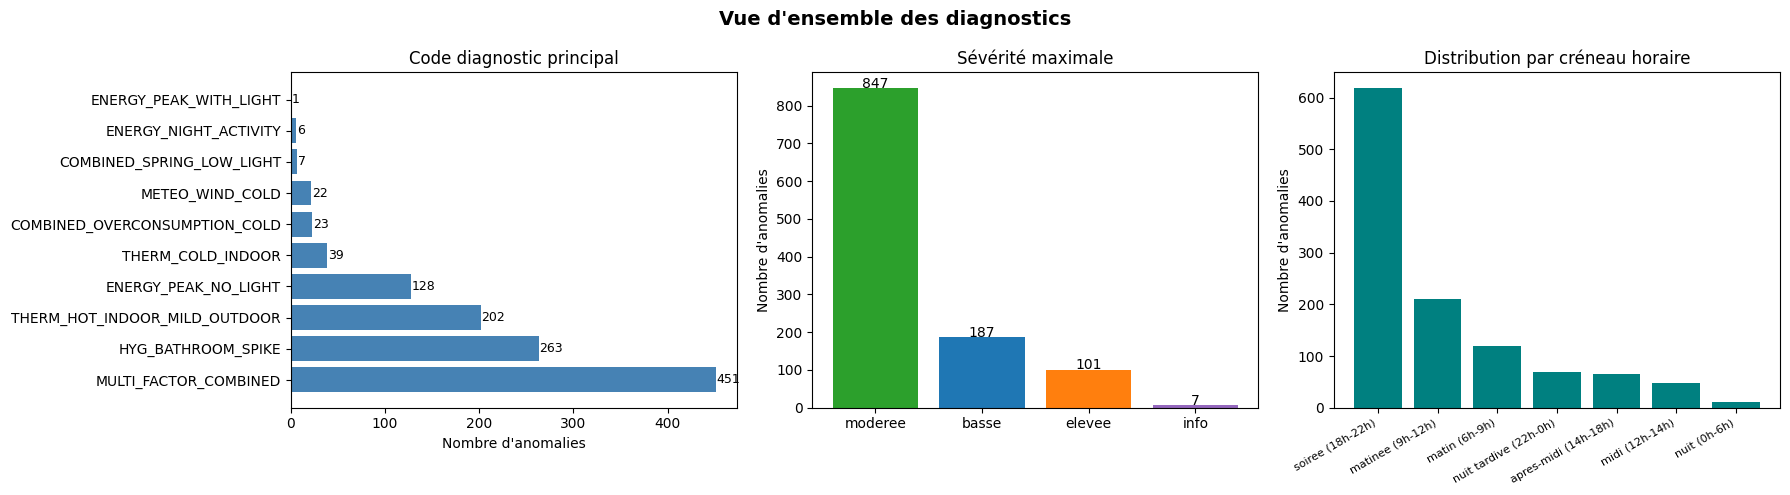

Graphique sauvegardé


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Vue d'ensemble des diagnostics", fontsize=14, fontweight="bold")

# 1. Codes de regles
code_counts = df_report["diagnostic_principal_code"].value_counts()
axes[0].barh(code_counts.index, code_counts.values, color="steelblue")
axes[0].set_title("Code diagnostic principal")
axes[0].set_xlabel("Nombre d'anomalies")
for i, v in enumerate(code_counts.values):
    axes[0].text(v+0.5, i, str(v), va="center", fontsize=9)

# 2. Severite max
sev_counts = df_report["severite_max"].value_counts()
colors_sev = {"critique":"#d62728","elevee":"#ff7f0e","moderee":"#2ca02c","basse":"#1f77b4","info":"#9467bd"}
colors = [colors_sev.get(s,"gray") for s in sev_counts.index]
axes[1].bar(sev_counts.index, sev_counts.values, color=colors)
axes[1].set_title("Sévérité maximale")
axes[1].set_ylabel("Nombre d'anomalies")
for i, v in enumerate(sev_counts.values):
    axes[1].text(i, v+0.5, str(v), ha="center", fontsize=10)

# 3. Repartition par creneau horaire
slot_counts = df_report["creneau"].value_counts()
axes[2].bar(range(len(slot_counts)), slot_counts.values, color="teal")
axes[2].set_xticks(range(len(slot_counts)))
axes[2].set_xticklabels(slot_counts.index, rotation=30, ha="right", fontsize=8)
axes[2].set_title("Distribution par créneau horaire")
axes[2].set_ylabel("Nombre d'anomalies")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r"\diagnostics_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé")

---
## Cellule 8 — Timeline des anomalies avec diagnostic

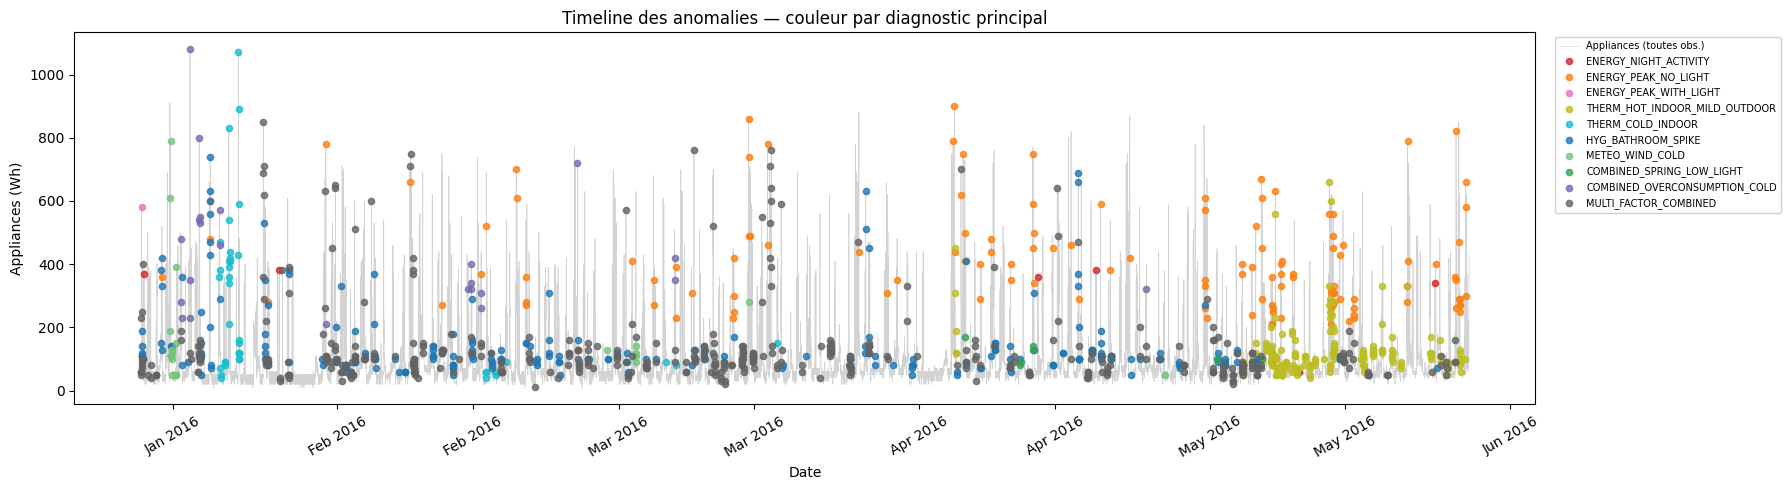

In [9]:
fig, ax = plt.subplots(figsize=(18, 5))

# Fond : consommation normale
ax.plot(df_raw["date"], df_raw["Appliances"], color="lightgray", linewidth=0.5, label="Appliances (toutes obs.)")

# Points par code de regle
palette = {
    "ENERGY_NIGHT_ACTIVITY"         : ("#d62728", "▲"),
    "ENERGY_PEAK_NO_LIGHT"          : ("#ff7f0e", "●"),
    "ENERGY_PEAK_WITH_LIGHT"        : ("#e377c2", "●"),
    "ENERGY_STANDBY_ANOMALY"        : ("#8c564b", "◆"),
    "THERM_HOT_INDOOR_MILD_OUTDOOR" : ("#bcbd22", "◆"),
    "THERM_COLD_INDOOR"             : ("#17becf", "◆"),
    "THERM_ASYMMETRY"               : ("#9467bd", "◆"),
    "HYG_BATHROOM_SPIKE"            : ("#1f77b4", "●"),
    "HYG_LAUNDRY_SPIKE"             : ("#aec7e8", "●"),
    "HYG_GLOBAL_HIGH"               : ("#6baed6", "▲"),
    "METEO_WIND_COLD"               : ("#74c476", "◆"),
    "COMBINED_SPRING_LOW_LIGHT"     : ("#31a354", "●"),
    "COMBINED_OVERCONSUMPTION_COLD" : ("#756bb1", "▲"),
    "MULTI_FACTOR_COMBINED"         : ("#636363", "●"),
}

for code, (color, _) in palette.items():
    mask = df_report["diagnostic_principal_code"] == code
    subset = df_report[mask]
    if len(subset) > 0:
        ax.scatter(subset["date"], subset["Appliances_Wh"],
                   color=color, s=20, label=code, zorder=3, alpha=0.8)

ax.set_xlabel("Date")
ax.set_ylabel("Appliances (Wh)")
ax.set_title("Timeline des anomalies — couleur par diagnostic principal")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + r"\diagnostics_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Cellule 9 — Exploration d'une anomalie spécifique

Modifie `IDX` pour explorer n'importe quelle anomalie du rapport.

In [10]:
# ============================================================
# MODIFIE IDX pour explorer une anomalie specifique
# 0 = premiere anomalie, -1 = derniere, ou n'importe quel index
# ============================================================
IDX = 0

row = df_report.iloc[IDX]

print("=" * 70)
print(f"  ANOMALIE #{IDX}  —  {row['date'].strftime('%A %d %B %Y à %Hh%M')}")
print(f"  Catégorie : {row['anomaly_category'].upper()}  |  Sévérité : {row['severity_pct']}%ile")
print(f"  Créneau   : {row['creneau']}  |  Saison : {row['saison']}  |  Weekend : {'Oui' if row['is_weekend'] else 'Non'}")
print("=" * 70)

print(f"\n  VALEURS BRUTES :")
print(f"    Appliances : {row['Appliances_Wh']} Wh  [{row['q_Appliances']} — {row['pct_Appliances']}%ile pour cette heure]")
print(f"    Lights     : {row['lights_Wh']} Wh  [{row['q_lights']}]")
print(f"    T cuisine  : {row['T1_cuisine_C']} C")
print(f"    T salon    : {row['T2_salon_C']} C  [{row['q_T2_salon']}]")
print(f"    T buanderie: {row['T3_buanderie_C']} C")
print(f"    T sdb      : {row['T5_sdb_C']} C")
print(f"    T extérieur: {row['T_out_C']} C  [{row['q_T_out']}]")
print(f"    RH buanderie: {row['RH_3_buanderie_pct']} %")
print(f"    RH sdb     : {row['RH_5_sdb_pct']} %  [{row['q_RH_5_sdb']}]")
print(f"    RH ext.    : {row['RH_out_pct']} %")
print(f"    Vent       : {row['Windspeed_ms']} m/s")

print(f"\n  RÈGLES ACTIVÉES ({row['nb_regles_activees']}) :")
for code in row['codes_regles'].split(' | '):
    print(f"    - {code}")

print(f"\n  DIAGNOSTIC COMPLET :")
print("-" * 70)
for bloc in row["diagnostic_complet"].split("\n---\n"):
    print(f"  {bloc}")
    print()

  ANOMALIE #0  —  Monday 11 January 2016 à 17h30
  Catégorie : MID  |  Sévérité : 96.26%ile
  Créneau   : apres-midi (14h-18h)  |  Saison : hiver  |  Weekend : Non

  VALEURS BRUTES :
    Appliances : 50.0 Wh  [BAS — 15.0%ile pour cette heure]
    Lights     : 40.0 Wh  [TRES_HAUT]
    T cuisine  : 19.89 C
    T salon    : 19.2 C  [BAS]
    T buanderie: 19.79 C
    T sdb      : 17.17 C
    T extérieur: 6.25 C  [NORMAL]
    RH buanderie: 45.0 %
    RH sdb     : 55.1 %  [TRES_HAUT]
    RH ext.    : 92.0 %
    Vent       : 6.0 m/s

  RÈGLES ACTIVÉES (1) :
    - MULTI_FACTOR_COMBINED

  DIAGNOSTIC COMPLET :
----------------------------------------------------------------------
  [MULTI_FACTOR_COMBINED / MODEREE] Anomalie MID (severite 96.3%ile) le 11/01/2016 a 17h30. Appareils=50 Wh (en dessous de la normale (bottom 25%) pour 17h), Eclairage=40 Wh, T_out=6.2C. Plusieurs signaux atypiques combines — investigation manuelle recommandee.



---
## Cellule 10 — Filtrage et exploration par critères

Exemples de filtres pour naviguer dans le rapport.

In [16]:
# ============================================================
# EXEMPLES DE FILTRES — decommenter / modifier selon le besoin
# ============================================================

# 1. Les 10 anomalies HIGH les plus severes
print("=== TOP 10 anomalies HIGH avec la plus grosse consommation énérgetique Wh ===")
top10 = (
    df_report[df_report["anomaly_category"] == "high"]
    .nlargest(10, "Appliances_Wh")
    [["date","severity_pct","Appliances_Wh","T_out_C",
      "diagnostic_principal_titre","diagnostic_principal_detail"]]
)
display(top10)

# 2. Anomalies nocturnes (0h-6h)
print("\n=== Anomalies nocturnes ===")
nuit = df_report[df_report["heure"].between(0,5)]
print(f"  {len(nuit)} anomalies entre 0h et 5h")
display(nuit[["date","heure","anomaly_category","Appliances_Wh","lights_Wh","diagnostic_principal_titre"]].head(11))

# 3. Anomalies liees a l'humidite
print("\n=== Anomalies hygriques ===")
hygro = df_report[df_report["codes_regles"].str.contains("HYG")]
print(f"  {len(hygro)} anomalies avec au moins une regle hygrique activee")
display(hygro[["date","heure","RH_3_buanderie_pct","RH_5_sdb_pct","Appliances_Wh","codes_regles"]].head(10))

# 4. Contexte printanier (eclairage coheremment nul)
print("\n=== Contexte printanier ===")
spring = df_report[df_report["codes_regles"].str.contains("SPRING")]
print(f"  {len(spring)} anomalies avec contexte printanier identifie")
display(spring[["date","heure","saison","lights_Wh","T_out_C","diagnostic_principal_detail"]].head(5))

=== TOP 10 anomalies HIGH avec la plus grosse consommation énérgetique Wh ===


,date,severity_pct,Appliances_Wh,T_out_C,diagnostic_principal_titre,diagnostic_principal_detail
59,2016-01-16 18:50:00,99.08,1080.0,2.08,Surconsommation par grand froid — effort de chauffage important,Consommation de 1080 Wh (extremement eleve (top 5%) pour 18h) avec T_out=2.1C. Effort de chauffage intense pour maintenir l'interieur a 21.9C.
121,2016-01-21 18:50:00,99.72,1070.0,-0.62,Sous-temperature interieure par temps froid,Temperature interieure minimale a 17.3C (seuil confort=18C) avec T_out=-0.6C. Systeme de chauffage insuffisant ou defaillant.
174,2016-01-30 19:10:00,99.78,780.0,4.20,Surconsommation d'appareils sans eclairage,"Les appareils consomment 780 Wh (extremement eleve (top 5%) pour 19h), alors que l'eclairage est quasi nul (0 Wh). Probable usage intensif d'appareils electromenagers (cuisine, buanderie) sans pre..."
375,2016-02-25 18:20:00,99.16,720.0,4.00,Surconsommation par grand froid — effort de chauffage important,Consommation de 720 Wh (extremement eleve (top 5%) pour 18h) avec T_out=4.0C. Effort de chauffage intense pour maintenir l'interieur a 20.9C.
694,2016-04-17 10:20:00,99.83,690.0,6.90,Humidite elevee en salle de bain,"Humidite salle de bain : 76% (extremement eleve (top 5%) pour 10h), hors des creneaux habituels. Douche/bain prolonge ou ventilation insuffisante."
695,2016-04-17 10:30:00,99.95,660.0,7.20,Humidite elevee en salle de bain,"Humidite salle de bain : 83% (extremement eleve (top 5%) pour 10h), hors des creneaux habituels. Douche/bain prolonge ou ventilation insuffisante."
90,2016-01-18 20:20:00,99.84,630.0,-2.67,Humidite elevee en salle de bain,"Humidite salle de bain : 85% (extremement eleve (top 5%) pour 20h), sur creneau habituel. Douche/bain prolonge ou ventilation insuffisante."
769,2016-04-30 12:30:00,99.65,610.0,9.10,Surconsommation d'appareils sans eclairage,"Les appareils consomment 610 Wh (extremement eleve (top 5%) pour 12h), alors que l'eclairage est quasi nul (0 Wh). Probable usage intensif d'appareils electromenagers (cuisine, buanderie) sans pre..."
721,2016-04-19 17:50:00,99.46,590.0,12.75,Surconsommation d'appareils sans eclairage,"Les appareils consomment 590 Wh (extremement eleve (top 5%) pour 17h), alors que l'eclairage est quasi nul (0 Wh). Probable usage intensif d'appareils electromenagers (cuisine, buanderie) sans pre..."
101,2016-01-19 20:20:00,99.54,570.0,-3.50,Surconsommation par grand froid — effort de chauffage important,Consommation de 570 Wh (extremement eleve (top 5%) pour 20h) avec T_out=-3.5C. Effort de chauffage intense pour maintenir l'interieur a 19.4C.



=== Anomalies nocturnes ===
  11 anomalies entre 0h et 5h


,date,heure,anomaly_category,Appliances_Wh,lights_Wh,diagnostic_principal_titre
21,2016-01-12 01:10:00,1,mid,370.0,20.0,Activite electrique anormale en pleine nuit
155,2016-01-26 00:10:00,0,mid,380.0,30.0,Activite electrique anormale en pleine nuit
156,2016-01-26 00:40:00,0,mid,40.0,30.0,Anomalie multi-facteurs sans pattern dominant
157,2016-01-26 01:10:00,1,mid,30.0,0.0,Anomalie multi-facteurs sans pattern dominant
166,2016-01-27 00:00:00,0,mid,50.0,20.0,Anomalie multi-facteurs sans pattern dominant
167,2016-01-27 00:10:00,0,mid,50.0,20.0,Anomalie multi-facteurs sans pattern dominant
168,2016-01-27 00:30:00,0,mid,40.0,0.0,Anomalie multi-facteurs sans pattern dominant
680,2016-04-13 05:30:00,5,mid,360.0,10.0,Activite electrique anormale en pleine nuit
720,2016-04-19 05:40:00,5,mid,380.0,0.0,Activite electrique anormale en pleine nuit
969,2016-05-10 05:50:00,5,mid,60.0,10.0,Activite electrique anormale en pleine nuit



=== Anomalies hygriques ===
  374 anomalies avec au moins une regle hygrique activee


,date,heure,RH_3_buanderie_pct,RH_5_sdb_pct,Appliances_Wh,codes_regles
11,2016-01-11 20:10:00,20,47.6,70.7,140.0,HYG_BATHROOM_SPIKE
12,2016-01-11 20:20:00,20,47.3,79.0,120.0,HYG_BATHROOM_SPIKE
13,2016-01-11 20:30:00,20,47.0,79.7,190.0,HYG_BATHROOM_SPIKE
14,2016-01-11 20:40:00,20,46.8,79.3,110.0,HYG_BATHROOM_SPIKE
15,2016-01-11 20:50:00,20,46.6,78.4,110.0,HYG_BATHROOM_SPIKE
16,2016-01-11 21:00:00,21,46.4,82.5,110.0,HYG_BATHROOM_SPIKE
17,2016-01-11 21:20:00,21,46.1,71.0,100.0,HYG_BATHROOM_SPIKE
25,2016-01-13 06:40:00,6,44.6,84.9,50.0,HYG_BATHROOM_SPIKE
28,2016-01-13 19:40:00,19,42.0,74.7,380.0,HYG_BATHROOM_SPIKE | COMBINED_OVERCONSUMPTION_COLD
29,2016-01-13 20:00:00,20,42.2,75.0,150.0,HYG_BATHROOM_SPIKE



=== Contexte printanier ===
  159 anomalies avec contexte printanier identifie


,date,heure,saison,lights_Wh,T_out_C,diagnostic_principal_detail
608,2016-04-04 12:20:00,12,printemps,0.0,13.47,"Les appareils consomment 790 Wh (extremement eleve (top 5%) pour 12h), alors que l'eclairage est quasi nul (0 Wh). Probable usage intensif d'appareils electromenagers (cuisine, buanderie) sans pre..."
609,2016-04-04 15:40:00,15,printemps,0.0,14.77,"Les appareils consomment 900 Wh (extremement eleve (top 5%) pour 15h), alors que l'eclairage est quasi nul (0 Wh). Probable usage intensif d'appareils electromenagers (cuisine, buanderie) sans pre..."
610,2016-04-04 16:20:00,16,printemps,0.0,14.83,"Les appareils consomment 440 Wh (extremement eleve (top 5%) pour 16h), alors que l'eclairage est quasi nul (0 Wh). Probable usage intensif d'appareils electromenagers (cuisine, buanderie) sans pre..."
613,2016-04-04 18:40:00,18,printemps,0.0,12.90,Temperature interieure maximale de 25.6C (buanderie) alors que T_out=12.9C (temps doux). Accumulation de chaleur liee a la consommation des appareils (190 Wh) sans ventilation naturelle.
614,2016-04-04 18:50:00,18,printemps,0.0,13.10,Temperature interieure maximale de 25.5C (buanderie) alors que T_out=13.1C (temps doux). Accumulation de chaleur liee a la consommation des appareils (120 Wh) sans ventilation naturelle.


---
## Cellule 11 — Contexte temporel d'une anomalie (fenêtre ±24h)

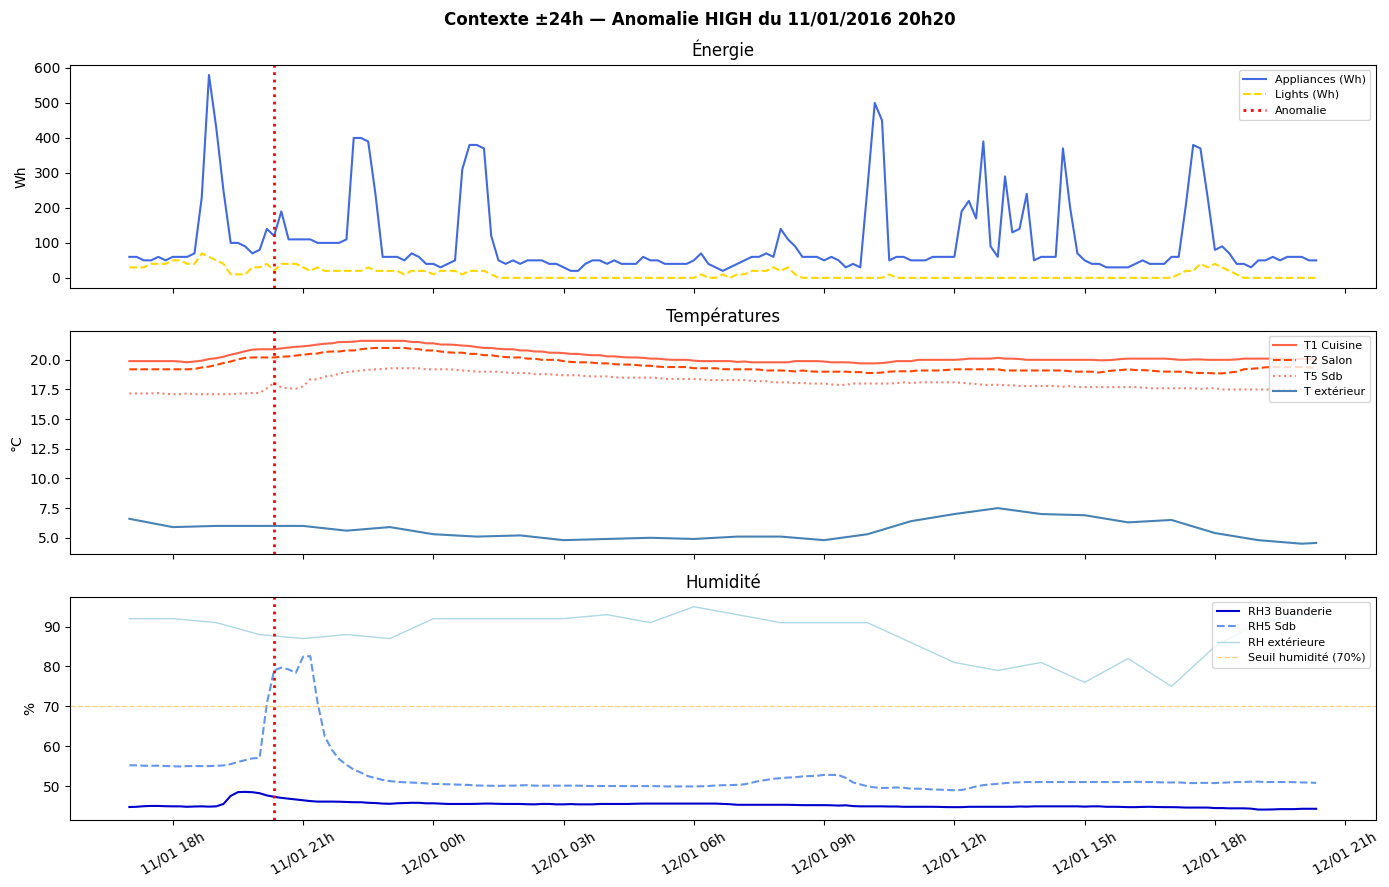

Règles activées : HYG_BATHROOM_SPIKE
Diagnostic : Humidite salle de bain : 79% (extremement eleve (top 5%) pour 20h), sur creneau habituel. Douche/bain prolonge ou ventilation insuffisante.


In [17]:
# ============================================================
# MODIFIE IDX pour visualiser le contexte d'une anomalie
# ============================================================
IDX = 12

row  = df_report.iloc[IDX]
t0   = row["date"]
mask = (df_raw["date"] >= t0 - pd.Timedelta(hours=24)) & \
       (df_raw["date"] <= t0 + pd.Timedelta(hours=24))
window = df_raw[mask]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f"Contexte ±24h — Anomalie {row['anomaly_category'].upper()} du {t0.strftime('%d/%m/%Y %Hh%M')}",
             fontsize=12, fontweight="bold")

# Energie
axes[0].plot(window["date"], window["Appliances"], label="Appliances (Wh)", color="royalblue")
axes[0].plot(window["date"], window["lights"],     label="Lights (Wh)",     color="gold", linestyle="--")
axes[0].axvline(t0, color="red", linewidth=2, linestyle=":", label="Anomalie")
axes[0].set_ylabel("Wh")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Énergie")

# Temperatures
axes[1].plot(window["date"], window["T1"], label="T1 Cuisine",   color="tomato")
axes[1].plot(window["date"], window["T2"], label="T2 Salon",     color="orangered", linestyle="--")
axes[1].plot(window["date"], window["T5"], label="T5 Sdb",       color="salmon",    linestyle=":")
axes[1].plot(window["date"], window["T_out"], label="T extérieur", color="steelblue", linewidth=1.5)
axes[1].axvline(t0, color="red", linewidth=2, linestyle=":")
axes[1].set_ylabel("°C")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title("Températures")

# Humidites
axes[2].plot(window["date"], window["RH_3"],   label="RH3 Buanderie",  color="mediumblue")
axes[2].plot(window["date"], window["RH_5"],   label="RH5 Sdb",        color="cornflowerblue", linestyle="--")
axes[2].plot(window["date"], window["RH_out"], label="RH extérieure",  color="lightblue", linewidth=1)
axes[2].axvline(t0, color="red", linewidth=2, linestyle=":")
axes[2].axhline(RH_HUMIDE, color="orange", linewidth=1, linestyle="--", alpha=0.5, label=f"Seuil humidité ({RH_HUMIDE}%)")
axes[2].set_ylabel("%")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].set_title("Humidité")

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + f"\\anomaly_context_IDX{IDX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Règles activées : {row['codes_regles']}")
print(f"Diagnostic : {row['diagnostic_principal_detail']}")